In [24]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd

# Initialize the Spotify API client
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="f6f6de34e09741d28b1766703ec2560a",
                                               client_secret="19cd0d5906204557934a27406a24e4ca",
                                               redirect_uri="http://localhost:8888/callback",
                                               scope="user-library-read playlist-modify-public playlist-read-private",
                                               requests_timeout=30))

In [ ]:
comp = pd.read_csv(r'./kinesandbeyondfall2024/competitors.csv')
roun = pd.read_csv(r'./kinesandbeyondfall2024/rounds.csv')
subm = pd.read_csv(r'./kinesandbeyondfall2024/submissions.csv')
vote = pd.read_csv(r'./kinesandbeyondfall2024/votes.csv')

vote = vote.merge(comp,left_on='Voter ID',right_on='ID')

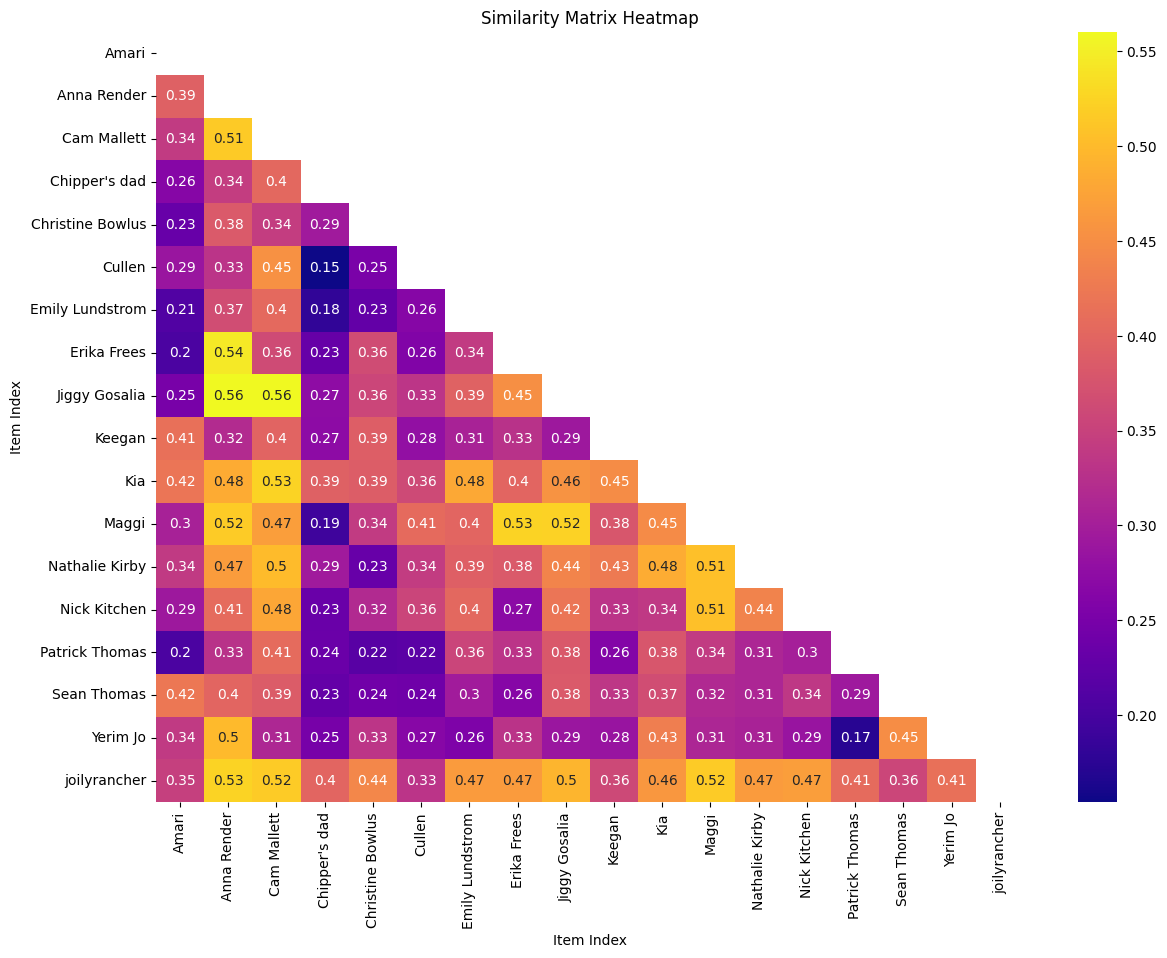

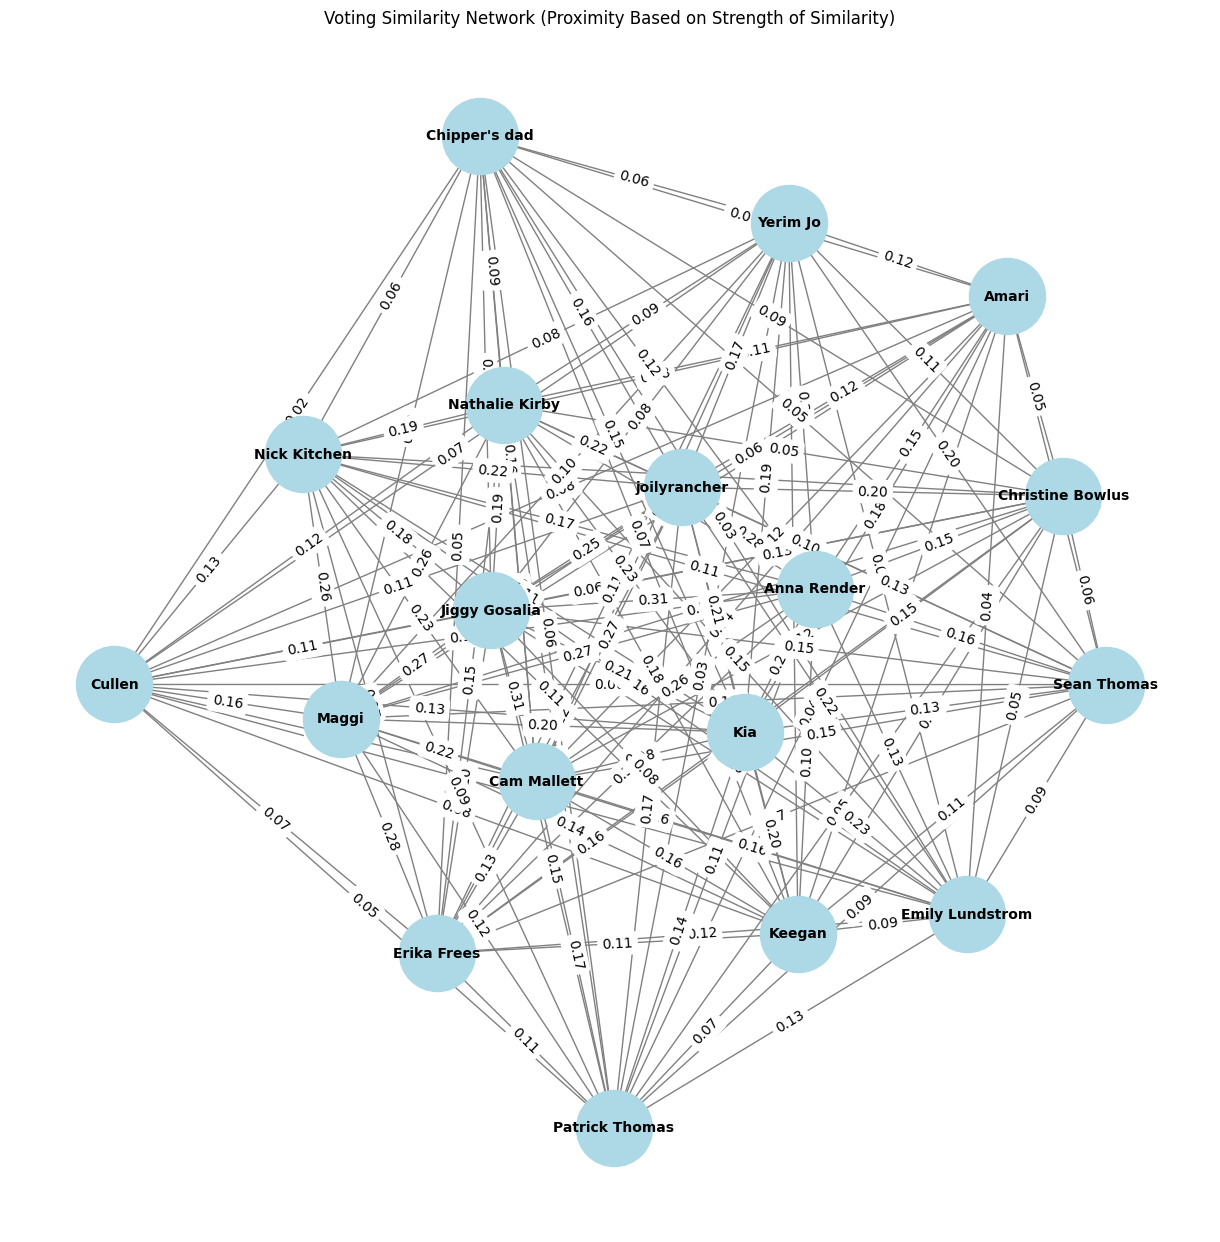

In [131]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import math
import seaborn as sns

# Create a pivot table of Points Assigned by Voter ID and Song

voter = vote[vote['Round ID'] == 'fd310df6d55c4a3d9062c53c89faf125']

pivot = vote.pivot_table(
    index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
)

# Compute the similarity matrix (cosine similarity)
similarity_matrix = cosine_similarity(pivot)
#similarity_matrix = np.dot(pivot, pivot.T)

# Convert the matrix to a DataFrame for easier manipulation
similarity_df = pd.DataFrame(
    similarity_matrix, index=pivot.index, columns=pivot.index
)
mask = np.triu(np.ones_like(similarity_df, dtype=bool))

similarity_df.to_csv('similarity_df.csv')

plt.figure(figsize=(14, 10))
sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

# Add labels
plt.title("Similarity Matrix Heatmap")
plt.xlabel("Item Index")
plt.ylabel("Item Index")
plt.savefig('heatmap.png')
# Show plot
plt.show()


# Create a graph using NetworkX
G = nx.Graph()

# Add nodes (Voter IDs)
for voter in similarity_df.index:
    G.add_node(voter)

# Add weighted edges based on similarity
for i, voter1 in enumerate(similarity_df.index):
    for j, voter2 in enumerate(similarity_df.columns):
        if i != j:  # Exclude self-similarity
            weight = similarity_df.iloc[i, j]
            if weight > 0:  # Add an edge only if there’s some similarity
                G.add_edge(voter1, voter2, weight=weight**2)

# Use a force-directed layout (spring layout) where edge weights determine proximity
pos = nx.spring_layout(G, weight='weight', seed=42)

# Visualize the graph
plt.figure(figsize=(12, 12))
nx.draw(
    G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
    node_size=3000, font_size=10, font_weight='bold'
)

# Add edge labels to show weights
edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {key: f"{value:.2f}" for key, value in edge_labels.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Voting Similarity Network (Proximity Based on Strength of Similarity)")
plt.savefig('../output/network graph fall songs.png')
plt.show()

In [16]:
# # Get current user's profile data
# user_profile = sp.user() #user id can be found in profile of the desktop app
# # Extract profile picture URL
# images = user_profile.get('images', [])
# if images:
#     profile_image_url = images[0]['url']
#     print(f"Profile Image URL: {profile_image_url}")
# else:
#     print("No profile image found.")